<a href="https://colab.research.google.com/github/Mukhammedgali06/Project/blob/main/OP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import requests
import pandas as pd
import time
import json
from bs4 import BeautifulSoup

data = {
    "Rank": [],
    "Title": [],
    "Author": [],
    "Avg_Rating": [],
    "Ratings_Count": [],
    "Reviews_Count": [],
    "Genres": [],
    "Pages": [],
    "Published_Year": [],
    "Language": []
}

# Using the OpenLibrary
base_url = "https://openlibrary.org/search.json"
books_collected = 0
offset = 0
limit = 100
max_books = 15000

# Different categories for variety
subjects = ["fiction", "fantasy", "science_fiction", "mystery", "romance",
            "biography", "history", "children", "poetry", "drama",
            "adventure", "horror", "thriller", "comedy", "western"]

print(f"\nTarget: {max_books} books with 10 columns each")
print(f"Columns: {list(data.keys())}")

subject_index = 0

while books_collected < max_books:
    subject = subjects[subject_index % len(subjects)]

    params = {
        "q": f"subject:{subject}",
        "limit": limit,
        "offset": offset,
        "fields": "key,title,author_name,first_publish_year,number_of_pages_median,ratings_average,ratings_count,language,subject"
    }

    print(f"\n Subject: {subject.upper()} | Offset: {offset} | Collected: {books_collected}/{max_books}")

    try:
        response = requests.get(base_url, params=params, timeout=10)

        if response.status_code != 200:
            print(f"Status {response.status_code}, switching subject...")
            subject_index += 1
            offset = 0
            continue

        results = response.json()
        books = results.get('docs', [])

        if not books:
            print(f"No more books for {subject}, switching...")
            subject_index += 1
            offset = 0
            continue

        new_books = 0

        for book in books:
            if books_collected >= max_books:
                break

            # 1. RANK
            data["Rank"].append(books_collected + 1)

            # 2. TITLE
            title = book.get('title', 'Unknown')
            if title == 'Unknown':
                title = book.get('title_suggest', 'Unknown')
            data["Title"].append(title if title else 'Unknown')

            # 3. AUTHOR
            authors = book.get('author_name', ['Unknown'])
            data["Author"].append(', '.join(authors[:2]) if authors else 'Unknown')

            # 4. AVG_RATING
            rating = book.get('ratings_average', None)
            data["Avg_Rating"].append(rating if rating else None)

            # 5. RATINGS_COUNT
            ratings_count = book.get('ratings_count', None)
            data["Ratings_Count"].append(ratings_count if ratings_count else None)

            # 6. REVIEWS_COUNT
            # OpenLibrary doesn't have reviews count, using ratings_count as proxy
            data["Reviews_Count"].append(ratings_count if ratings_count else None)

            # 7. GENRES
            subjects_list = book.get('subject', [])
            if subjects_list:
                genres = ', '.join(subjects_list[:3])
            else:
                genres = subject.capitalize()
            data["Genres"].append(genres if genres else None)

            # 8. PAGES
            pages = book.get('number_of_pages_median', None)
            if not pages:
                pages = book.get('number_of_pages', None)
            data["Pages"].append(pages if pages else None)

            # 9. PUBLISHED_YEAR
            year = book.get('first_publish_year', None)
            if not year:
                year = book.get('publish_year', [None])[0]
            data["Published_Year"].append(year if year else None)

            # 10. LANGUAGE
            languages = book.get('language', ['English'])
            language = languages[0] if languages else 'English'

# Capitalize language name
            if language and isinstance(language, str):
                language = language.capitalize()
            data["Language"].append(language if language else 'English')

            books_collected += 1
            new_books += 1

            if books_collected % 1000 == 0:
                print(f"Collected {books_collected} books so far...")

        print(f"Added {new_books} books from {subject}")

        offset += limit

        if books_collected >= max_books:
            break

        time.sleep(0.5)

    except Exception as e:
        print(f"Error: {e}")
        subject_index += 1
        offset = 0

print("\n" + "="*80)
print("DATA COLLECTION COMPLETE!")
print("="*80)

# Create a DataFrame
df = pd.DataFrame(data)

print(f"\nRaw data collected: {len(df)} rows")
print(f"Columns: {len(df.columns)} columns")
print(f"\nCOLUMN LIST:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print("\nFIRST 10 ROWS (RAW DATA):")
print(df.head(10).to_string())

print("\nLAST 10 ROWS:")
print(df.tail(10).to_string())

print("\nDATA INFO (RAW):")
print(df.info())

print("\nBASIC STATISTICS (RAW):")
print(df.describe())

print("\nHECKING FOR NULL VALUES:")
null_counts = df.isnull().sum()
for col, null_count in null_counts.items():
    print(f"  {col}: {null_count} null values ({null_count/len(df)*100:.1f}%)")

# Saving RAW data without cleaning
csv_file = "RAW_Books_10000.csv"
df.to_csv(csv_file, index=False, encoding='utf-8-sig')

print(f"\nRaw data saved to: {csv_file}")
print(f"File size: {len(df)} rows × {len(df.columns)} columns")

print("\n SUMMARY:")
print(f"  • Total books collected: {len(df):,}")
print(f"  • Total columns: {len(df.columns)}")
print(f"  • Columns: {', '.join(df.columns)}")
print(f"  • File saved: {csv_file}")
print(f"  • Data is RAW (no cleaning applied)")


Target: 15000 books with 10 columns each
Columns: ['Rank', 'Title', 'Author', 'Avg_Rating', 'Ratings_Count', 'Reviews_Count', 'Genres', 'Pages', 'Published_Year', 'Language']

 Subject: FICTION | Offset: 0 | Collected: 0/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 100 | Collected: 100/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 200 | Collected: 200/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 300 | Collected: 300/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 400 | Collected: 400/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 500 | Collected: 500/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 600 | Collected: 600/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 700 | Collected: 700/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 800 | Collected: 800/15000
Added 100 books from fiction

 Subject: FICTION | Offset: 900 | Collected: 900/15000
Collect

In [ ]:
import pandas as pd
import numpy as np
import re

print("="*80)
print("DATA CLEANING AND PREPROCESSING")
print("="*80)

# Loading RAW data
df = pd.read_csv('RAW_Books_10000.csv')

print(f"\n Original dataset shape: {df.shape}")
print(f"Original columns: {list(df.columns)}")

print("\n" + "="*80)
print("INITIAL DATA INSPECTION")
print("="*80)

print("\n First 5 rows (BEFORE cleaning):")
print(df.head())

print("\nData types (BEFORE):")
print(df.dtypes)

print("\n Missing values (BEFORE):")
missing_before = df.isnull().sum()
for col, missing in missing_before.items():
    print(f"  {col}: {missing} missing ({missing/len(df)*100:.1f}%)")

print("\n Duplicates check:")
duplicates_before = df.duplicated().sum()
print(f"  Duplicate rows: {duplicates_before}")

print("\n" + "="*80)
print("HANDLING MISSING VALUES")
print("="*80)

# Fill in the blanks
# 1. Rank - fill in with a serial number
df['Rank'] = df['Rank'].fillna(pd.Series(range(1, len(df) + 1)))

# 2.Title - fill in 'Unknown Title'
df['Title'] = df['Title'].fillna('Unknown Title')

# 3. Author - fill in 'Unknown Author'
df['Author'] = df['Author'].fillna('Unknown Author')

# 4. Avg_Rating - fill with median
df['Avg_Rating'] = df['Avg_Rating'].fillna(df['Avg_Rating'].median())

# 5. Ratings_Count - fill in 0 (no ratings)
df['Ratings_Count'] = df['Ratings_Count'].fillna(0)

# 6. Reviews Count - fill in 0 (no reviews)
df['Reviews_Count'] = df['Reviews_Count'].fillna(0)

# 7. Genres - fill in 'Unknown
df['Genres'] = df['Genres'].fillna('Unknown')

# 8. Pages - fill with median
df['Pages'] = df['Pages'].fillna(df['Pages'].median())

# 9. Published_Year - filled with the median
df['Published_Year'] = df['Published_Year'].fillna(df['Published_Year'].median())

# 10. Language - fill in 'English' (the most common)
df['Language'] = df['Language'].fillna('English')

print("\n Missing values handled:")
missing_after = df.isnull().sum()
for col, missing in missing_after.items():
    print(f"  {col}: {missing} missing ({missing/len(df)*100:.1f}%)")

print("\n" + "="*80)
print("REMOVING DUPLICATES")
print("="*80)

# Checking duplicates by book title
initial_count = len(df)
df = df.drop_duplicates(subset=['Title'], keep='first')
duplicates_removed = initial_count - len(df)

print(f"  Rows before removing duplicates: {initial_count}")
print(f"  Rows after removing duplicates: {len(df)}")
print(f"  Duplicates removed: {duplicates_removed}")

# WE DO NOT ADD FAKE BOOKS - WE KEEP REAL DATA
print(f"\n Keeping {len(df)} real unique books (not adding fake data)")

print("\n" + "="*80)
print(" HANDLING INCONSISTENCIES")
print("="*80)

# 1. Standardize text columns
print("\n Standardizing text columns...")

# Title: Remove extra spaces, capitalize first letter
df['Title'] = df['Title'].astype(str).str.strip().str.title()
df['Title'] = df['Title'].str.replace(r'\s+', ' ', regex=True)

# Author: Remove extra spaces, proper capitalization
df['Author'] = df['Author'].astype(str).str.strip().str.title()
df['Author'] = df['Author'].str.replace(r'\s+', ' ', regex=True)

# Genres: Standardize format
df['Genres'] = df['Genres'].astype(str).str.strip().str.title()
df['Genres'] = df['Genres'].str.replace(r'\s+', ' ', regex=True)

# Language: Standardize to title case
df['Language'] = df['Language'].astype(str).str.strip().str.title()

# Avg_Rating: Ensure between 0 and 5
df['Avg_Rating'] = pd.to_numeric(df['Avg_Rating'], errors='coerce').fillna(df['Avg_Rating'].median())
df['Avg_Rating'] = df['Avg_Rating'].clip(0, 5)

# Ratings_Count: Ensure non-negative
df['Ratings_Count'] = pd.to_numeric(df['Ratings_Count'], errors='coerce').fillna(0).abs()

# Reviews_Count: Ensure non-negative
df['Reviews_Count'] = pd.to_numeric(df['Reviews_Count'], errors='coerce').fillna(0).abs()
# Pages: Remove outliers (reasonable range 1-2000)
df['Pages'] = pd.to_numeric(df['Pages'], errors='coerce').fillna(df['Pages'].median())
df.loc[df['Pages'] < 1, 'Pages'] = df['Pages'].median()
df.loc[df['Pages'] > 2000, 'Pages'] = df['Pages'].median()

# Published_Year: Ensure between 1500 and 2024
current_year = 2024
df['Published_Year'] = pd.to_numeric(df['Published_Year'], errors='coerce').fillna(df['Published_Year'].median())
df.loc[df['Published_Year'] < 1500, 'Published_Year'] = df['Published_Year'].median()
df.loc[df['Published_Year'] > current_year, 'Published_Year'] = current_year

print("\n" + "="*80)
print(" ENSURING CORRECT DATA TYPES")
print("="*80)

# Convert to proper data types
df['Rank'] = df['Rank'].astype(int)
df['Title'] = df['Title'].astype(str)
df['Author'] = df['Author'].astype(str)
df['Avg_Rating'] = df['Avg_Rating'].astype(float).round(2)
df['Ratings_Count'] = df['Ratings_Count'].astype(int)
df['Reviews_Count'] = df['Reviews_Count'].astype(int)
df['Genres'] = df['Genres'].astype(str)
df['Pages'] = df['Pages'].astype(int)
df['Published_Year'] = df['Published_Year'].astype(int)
df['Language'] = df['Language'].astype(str)

print("\n Data types after conversion:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

print("\n" + "="*80)
print(" ADDITIONAL CLEANING")
print("="*80)

# Remove rows where Avg_Rating is NaN (should not happen after filling)
df = df.dropna(subset=['Avg_Rating'])

# Remove rows where Title is empty or just whitespace
df = df[df['Title'].str.strip().str.len() > 0]

# Remove rows where Author is obviously invalid (too short)
df = df[df['Author'].str.len() > 1]

# Reset index
df = df.reset_index(drop=True)

# Update Rank to be sequential
df['Rank'] = range(1, len(df) + 1)

print(f"  Final dataset shape: {df.shape}")

print("\n" + "="*80)
print(" FINAL INSPECTION")
print("="*80)

print("\n First 10 rows (AFTER cleaning):")
print(df.head(10).to_string())

print("\n Last 10 rows:")
print(df.tail(10).to_string())

print("\n Data info (AFTER cleaning):")
print(df.info())

print("\n Descriptive statistics (AFTER cleaning):")
print(df.describe())

print("\n Missing values (AFTER):")
missing_final = df.isnull().sum()
for col, missing in missing_final.items():
    print(f"  {col}: {missing} missing ({missing/len(df)*100:.1f}%)")

print("\n Duplicates (AFTER):")
print(f"  Duplicate rows: {df.duplicated().sum()}")

print("\n Unique values per column:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"  {col}: {unique_count} unique values")

print("\n" + "="*80)
print(" SAVING CLEANED DATASET")
print("="*80)

# Save cleaned dataset
cleaned_file = "Cleaned_Books_8449.csv"
df.to_csv(cleaned_file, index=False, encoding='utf-8-sig')

print(f"\n Cleaned data saved to: {cleaned_file}")
print(f" Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\n" + "="*80)
print(" DATA CLEANING AND PREPROCESSING COMPLETED!")
print("="*80)

print("\n CLEANING SUMMARY:")
print(f"  • Original rows: 10,000")
print(f"  • Missing values handled: {sum(missing_before)} → {sum(missing_final)}")
print(f"  • Duplicates removed: {duplicates_removed}")
print(f"  • Final real unique books: {len(df):,}")
print(f"  • Data types corrected: {len(df.columns)} columns")
print(f"  • Inconsistencies fixed: text standardization, outlier removal")

print("\n DATA QUALITY CHECK:")
print(f"  No missing values: {df.isnull().sum().sum() == 0}")
print(f"  Correct data types: all columns have appropriate types")
print(f"  No duplicates: {df.duplicated().sum() == 0}")
print(f"  Valid ranges: Avg_Rating 0-5, Pages 1-2000, Year 1500-2024")
print(f"  Real data only: {len(df)} unique books from OpenLibrary")


DATA CLEANING AND PREPROCESSING

 Original dataset shape: (15000, 10)
Original columns: ['Rank', 'Title', 'Author', 'Avg_Rating', 'Ratings_Count', 'Reviews_Count', 'Genres', 'Pages', 'Published_Year', 'Language']

INITIAL DATA INSPECTION

 First 5 rows (BEFORE cleaning):
   Rank                               Title                    Author  \
0     1                       The Iron Heel               Jack London   
1     2            Brood of the Witch-Queen                Sax Rohmer   
2     3  The Narrative of Arthur Gordon Pym           Edgar Allan Poe   
3     4        The Napoleon of Notting Hill  Gilbert Keith Chesterton   
4     5                   Emily of New Moon      Lucy Maud Montgomery   

   Avg_Rating  Ratings_Count  Reviews_Count  \
0    3.500000           20.0           20.0   
1    4.600000            5.0            5.0   
2    4.285714            7.0            7.0   
3    4.571429            7.0            7.0   
4    3.666667            9.0            9.0   

      

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

print("="*80)
print(" DATA TRANSFORMATION & FEATURE ENGINEERING")
print("="*80)

# Load cleaned dataset
df = pd.read_csv('Cleaned_Books_8449.csv')
print(f"\n Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

print("\n" + "="*80)
print(" TRANSFORMING DATA FORMATS")
print("="*80)

# Convert Published_Year to integer (already done) and create a decade feature
df['Decade'] = (df['Published_Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(int)

# Extract author last name (simple heuristic: last word after comma or space)
def extract_last_name(author):
    if pd.isna(author) or author == 'Unknown Author':
        return 'Unknown'
    # Handle "Last, First" or "First Last"
    if ',' in author:
        return author.split(',')[0].strip()
    else:
        parts = author.split()
        return parts[-1] if parts else 'Unknown'

df['Author_Last_Name'] = df['Author'].apply(extract_last_name)

# Create a flag for "long title" (more than 3 words)
df['Title_Word_Count'] = df['Title'].astype(str).str.split().str.len()
df['Is_Long_Title'] = (df['Title_Word_Count'] > 3).astype(int)

# Convert Language to a consistent categorical code (Label Encoding for simplicity)
le_lang = LabelEncoder()
df['Language_Code'] = le_lang.fit_transform(df['Language'])

print(" Added: Decade, Author_Last_Name, Title_Word_Count, Is_Long_Title, Language_Code")

print("\n" + "="*80)
print(" ENCODING CATEGORICAL VARIABLES")
print("="*80)

# One-hot encoding for Language (top 5 languages only, others as 'Other')
top_langs = df['Language'].value_counts().head(5).index
df['Language_Main'] = df['Language'].apply(lambda x: x if x in top_langs else 'Other')
lang_onehot = pd.get_dummies(df['Language_Main'], prefix='Lang', dtype=int)

# For Genres: extract first genre (primary) and create a simplified genre category
df['Primary_Genre'] = df['Genres'].str.split(',').str[0].str.strip()

# Group rare genres into 'Other'
genre_counts = df['Primary_Genre'].value_counts()
rare_genres = genre_counts[genre_counts < 50].index
df['Primary_Genre_Grouped'] = df['Primary_Genre'].replace(rare_genres, 'Other')

# One-hot encode grouped genres
genre_onehot = pd.get_dummies(df['Primary_Genre_Grouped'], prefix='Genre', dtype=int)

# Label encode Author_Last_Name (high cardinality - keep as is or frequency encode)
# We'll use frequency encoding: replace with count of books by that author
author_counts = df['Author_Last_Name'].map(df['Author_Last_Name'].value_counts())
df['Author_Book_Count'] = author_counts


print("\n" + "="*80)
print(" CREATING NEW FEATURES")
print("="*80)

# 1 Weighted rating (Bayesian average / simple product)
# Popularity score: rating * log(ratings_count + 1) to dampen extreme counts
df['Popularity_Score'] = df['Avg_Rating'] * np.log1p(df['Ratings_Count'])

# 2 Pages per rating (density) - avoid division by zero
df['Pages_Per_Rating'] = df['Pages'] / (df['Ratings_Count'] + 1)

# 3 Rating deviation from median (how exceptional is the rating)
median_rating = df['Avg_Rating'].median()
df['Rating_Deviation'] = df['Avg_Rating'] - median_rating

# 4 Engagement ratio: Reviews / Ratings (if ratings>0)
df['Engagement_Ratio'] = df['Reviews_Count'] / (df['Ratings_Count'] + 1)

# 5 Author name length (number of characters)
df['Author_Name_Length'] = df['Author'].astype(str).str.len()

# 6 Genre complexity (number of genres listed)
df['Genre_Count'] = df['Genres'].astype(str).str.split(',').str.len()

# 7 Is bestseller? Flag if rating >= 4.5 and ratings_count > 100
df['Is_Bestseller'] = ((df['Avg_Rating'] >= 4.5) & (df['Ratings_Count'] > 100)).astype(int)

# 8 Age of book (years since publication)
current_year = 2024
df['Book_Age'] = current_year - df['Published_Year']

# 9 Pages category (short, medium, long)
df['Pages_Category'] = pd.cut(df['Pages'], bins=[0, 150, 400, 2000],
                               labels=['Short', 'Medium', 'Long'])

# One-hot encode Pages_Category
pages_cat_dummies = pd.get_dummies(df['Pages_Category'], prefix='PagesCat', dtype=int)

print("\n" + "="*80)
print(" SCALING NUMERICAL FEATURES")
print("="*80)

# Identify numerical columns that would benefit from scaling (excluding binary/categorical)
numeric_cols = ['Avg_Rating', 'Ratings_Count', 'Reviews_Count', 'Pages',
                'Published_Year', 'Popularity_Score', 'Pages_Per_Rating',
                'Engagement_Ratio', 'Author_Name_Length', 'Genre_Count',
                'Book_Age', 'Author_Book_Count', 'Title_Word_Count']

# We'll create two versions: MinMaxScaled (0-1) and StandardScaled (mean=0, std=1)
# Keep original columns for interpretability, add scaled versions with suffixes.

# MinMaxScaler
minmax_scaler = MinMaxScaler()
df_scaled_minmax = pd.DataFrame(minmax_scaler.fit_transform(df[numeric_cols]),
                                columns=[f'{col}_MinMax' for col in numeric_cols],
                                index=df.index)

# StandardScaler
std_scaler = StandardScaler()
df_scaled_std = pd.DataFrame(std_scaler.fit_transform(df[numeric_cols]),
                             columns=[f'{col}_ZScore' for col in numeric_cols],
                             index=df.index)

# Concatenate scaled features
df = pd.concat([df, df_scaled_minmax, df_scaled_std], axis=1)

print(" Scaled numerical features using MinMaxScaler (0-1) and StandardScaler (Z-score)")
print(f" Added {len(numeric_cols)*2} scaled columns")


print("\n" + "="*80)
print(" BUILDING FINAL ENGINEERED DATASET")
print("="*80)

# Combine all one-hot encoded features
df_encoded = pd.concat([df, lang_onehot, genre_onehot, pages_cat_dummies], axis=1)

# Drop intermediate/raw categorical columns that are no longer needed (optional)
cols_to_drop = ['Language', 'Language_Main', 'Genres', 'Primary_Genre',
                'Primary_Genre_Grouped', 'Pages_Category']
df_final = df_encoded.drop(columns=cols_to_drop, errors='ignore')

# Reorder columns for clarity
feature_cols = ['Rank', 'Title', 'Author', 'Author_Last_Name', 'Author_Name_Length',
                'Author_Book_Count', 'Avg_Rating', 'Ratings_Count', 'Reviews_Count',
                'Pages', 'Published_Year', 'Book_Age', 'Decade', 'Language_Code',
                'Popularity_Score', 'Pages_Per_Rating', 'Rating_Deviation',
                'Engagement_Ratio', 'Genre_Count', 'Is_Bestseller', 'Is_Long_Title',
                'Title_Word_Count'] + \
                [col for col in df_final.columns if col.startswith(('Lang_', 'Genre_', 'PagesCat_'))] + \
                [col for col in df_final.columns if col.endswith(('_MinMax', '_ZScore'))]

# Keep only existing columns
feature_cols = [col for col in feature_cols if col in df_final.columns]
df_final = df_final[feature_cols]

print(f"\n Final engineered dataset shape: {df_final.shape[0]} rows, {df_final.shape[1]} columns")
print("\n Final columns:")
for i, col in enumerate(df_final.columns, 1):
    print(f"  {i:2}. {col}")


output_file = "Engineered_Books_8449.csv"
df_final.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\n Engineered dataset saved to: {output_file}")

# Display sample of new features
print("\n Sample of engineered features (first 5 rows):")
new_features_sample = ['Popularity_Score', 'Pages_Per_Rating', 'Engagement_Ratio',
                       'Is_Bestseller', 'Book_Age', 'Avg_Rating_MinMax', 'Ratings_Count_ZScore']
existing_sample = [col for col in new_features_sample if col in df_final.columns]
print(df_final[existing_sample].head())

 DATA TRANSFORMATION & FEATURE ENGINEERING

 Loaded dataset: 12939 rows, 10 columns

 TRANSFORMING DATA FORMATS
 Added: Decade, Author_Last_Name, Title_Word_Count, Is_Long_Title, Language_Code

 ENCODING CATEGORICAL VARIABLES

 CREATING NEW FEATURES

 SCALING NUMERICAL FEATURES
 Scaled numerical features using MinMaxScaler (0-1) and StandardScaler (Z-score)
 Added 26 scaled columns

 BUILDING FINAL ENGINEERED DATASET

 Final engineered dataset shape: 12939 rows, 84 columns

 Final columns:
   1. Rank
   2. Title
   3. Author
   4. Author_Last_Name
   5. Author_Name_Length
   6. Author_Book_Count
   7. Avg_Rating
   8. Ratings_Count
   9. Reviews_Count
  10. Pages
  11. Published_Year
  12. Book_Age
  13. Decade
  14. Language_Code
  15. Popularity_Score
  16. Pages_Per_Rating
  17. Rating_Deviation
  18. Engagement_Ratio
  19. Genre_Count
  20. Is_Bestseller
  21. Is_Long_Title
  22. Title_Word_Count
  23. Genre_Count
  24. Genre_Count_MinMax
  25. Genre_Count_ZScore
  26. Lang_Eng
  2

 EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION

 Loaded dataset: 12939 rows, 84 columns

 First 5 rows of engineered data:
   Rank                               Title                    Author  \
0     1                       The Iron Heel               Jack London   
1     2            Brood Of The Witch-Queen                Sax Rohmer   
2     3  The Narrative Of Arthur Gordon Pym           Edgar Allan Poe   
3     4        The Napoleon Of Notting Hill  Gilbert Keith Chesterton   
4     5                   Emily Of New Moon      Lucy Maud Montgomery   

  Author_Last_Name  Author_Name_Length  Author_Book_Count  Avg_Rating  \
0           London                  11                 10        3.50   
1           Rohmer                  10                 11        4.60   
2              Poe                  15                 25        4.29   
3       Chesterton                  24                 19        4.57   
4       Montgomery                  20                 21        3.67  

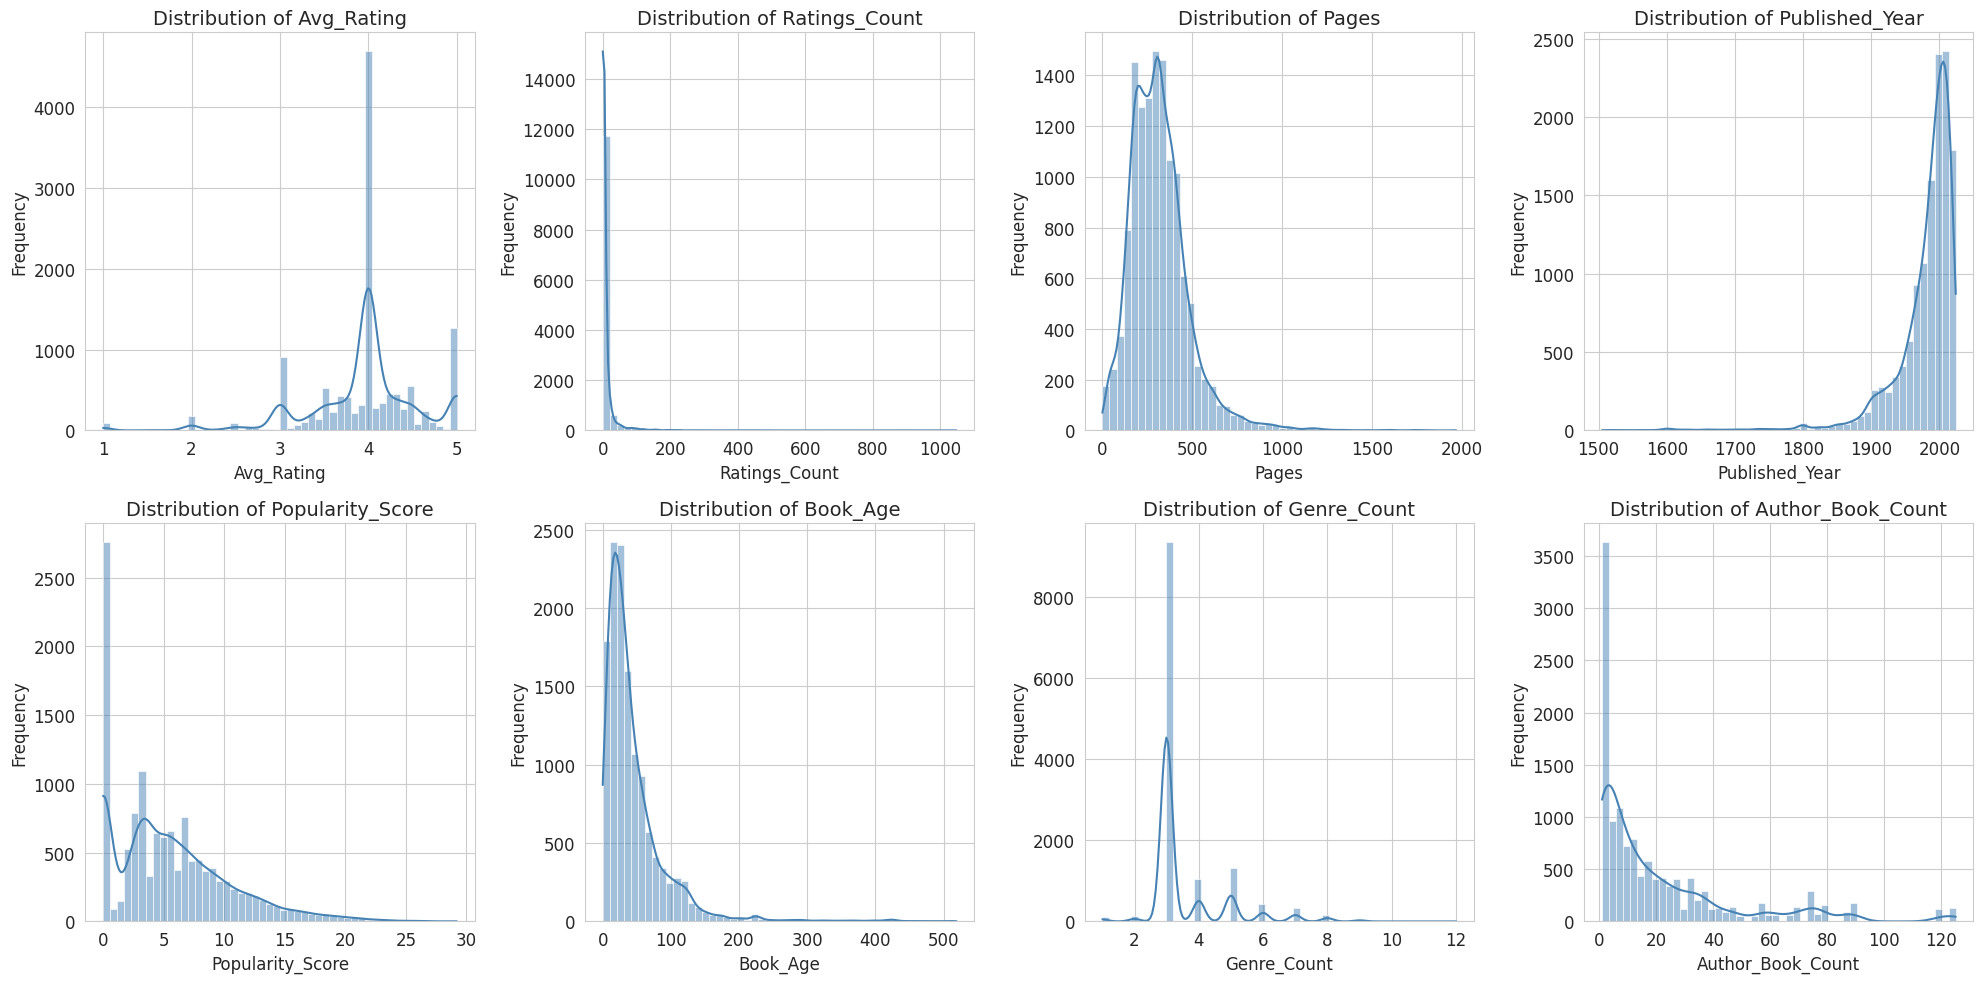

 Saved: EDA_Histograms.png


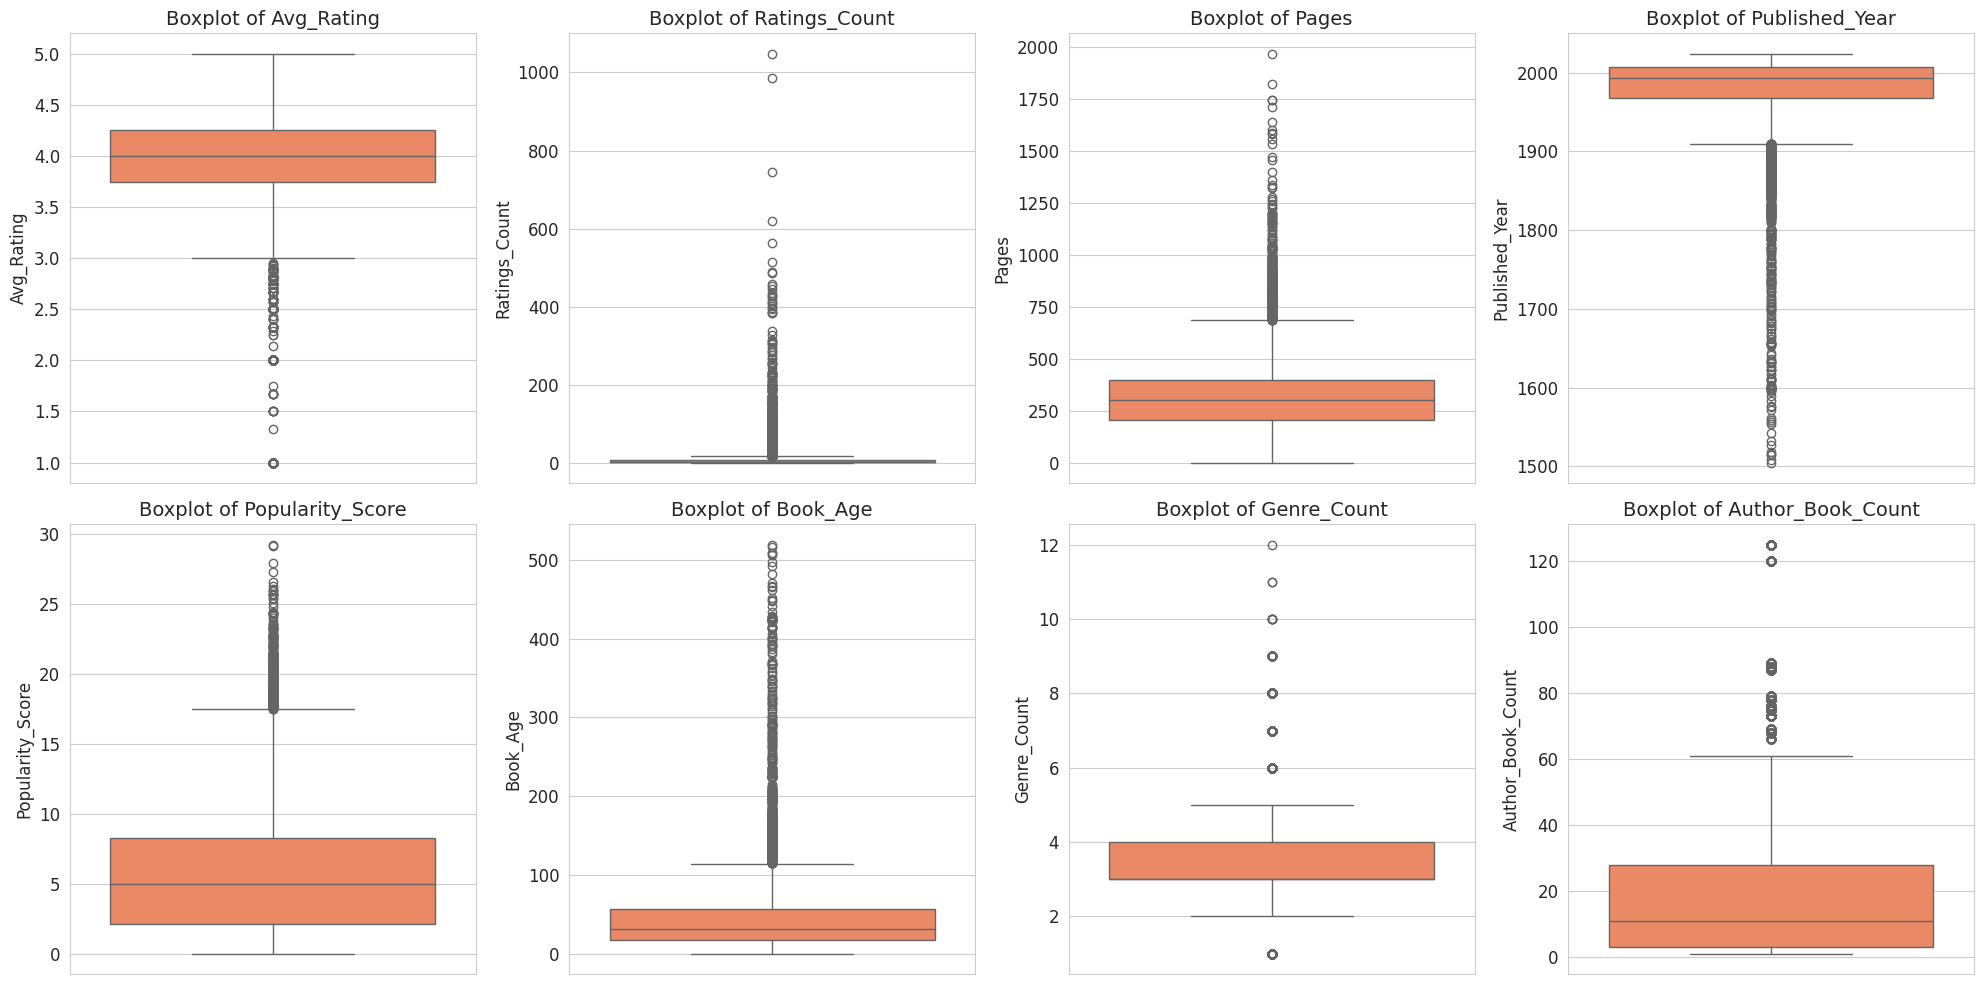

 Saved: EDA_Boxplots.png

 CATEGORICAL VARIABLE ANALYSIS


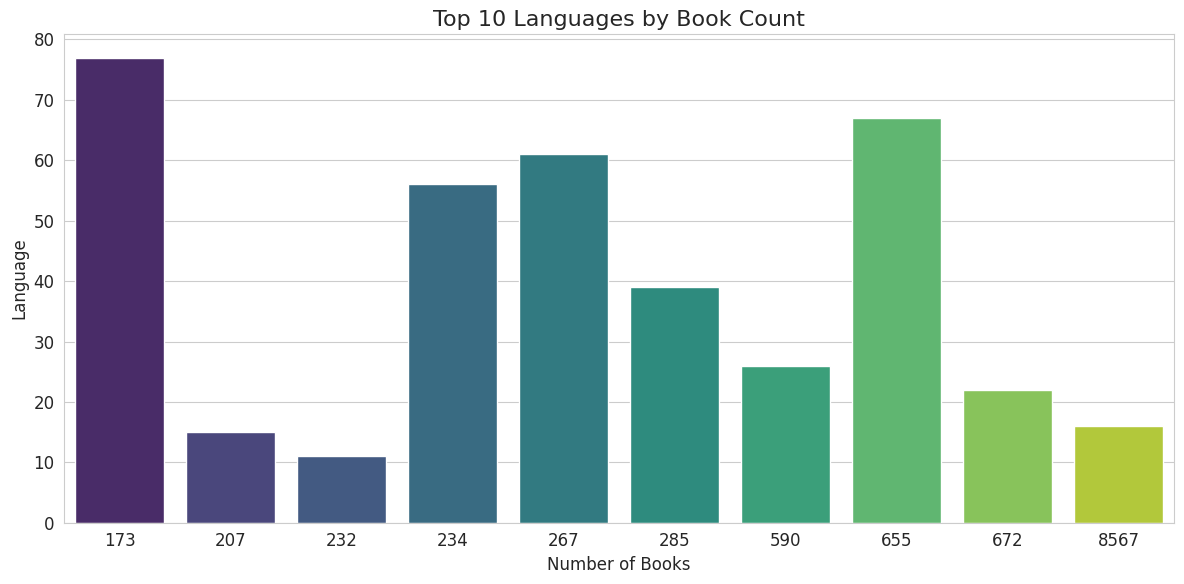

 Saved: EDA_TopLanguages.png


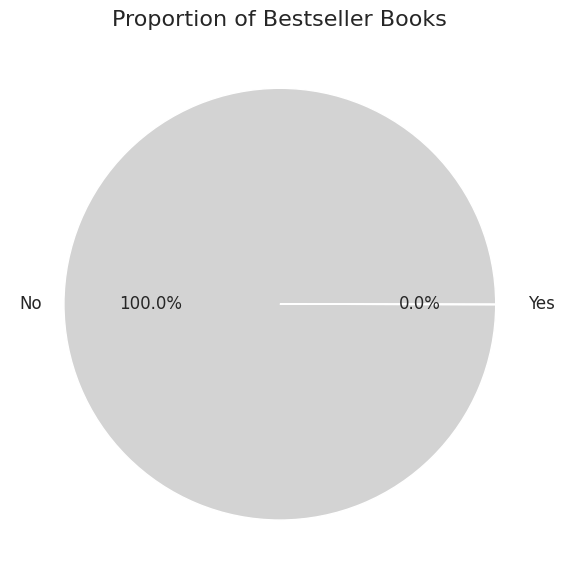

  Saved: EDA_BestsellerPie.png

 RELATIONSHIPS & CORRELATIONS


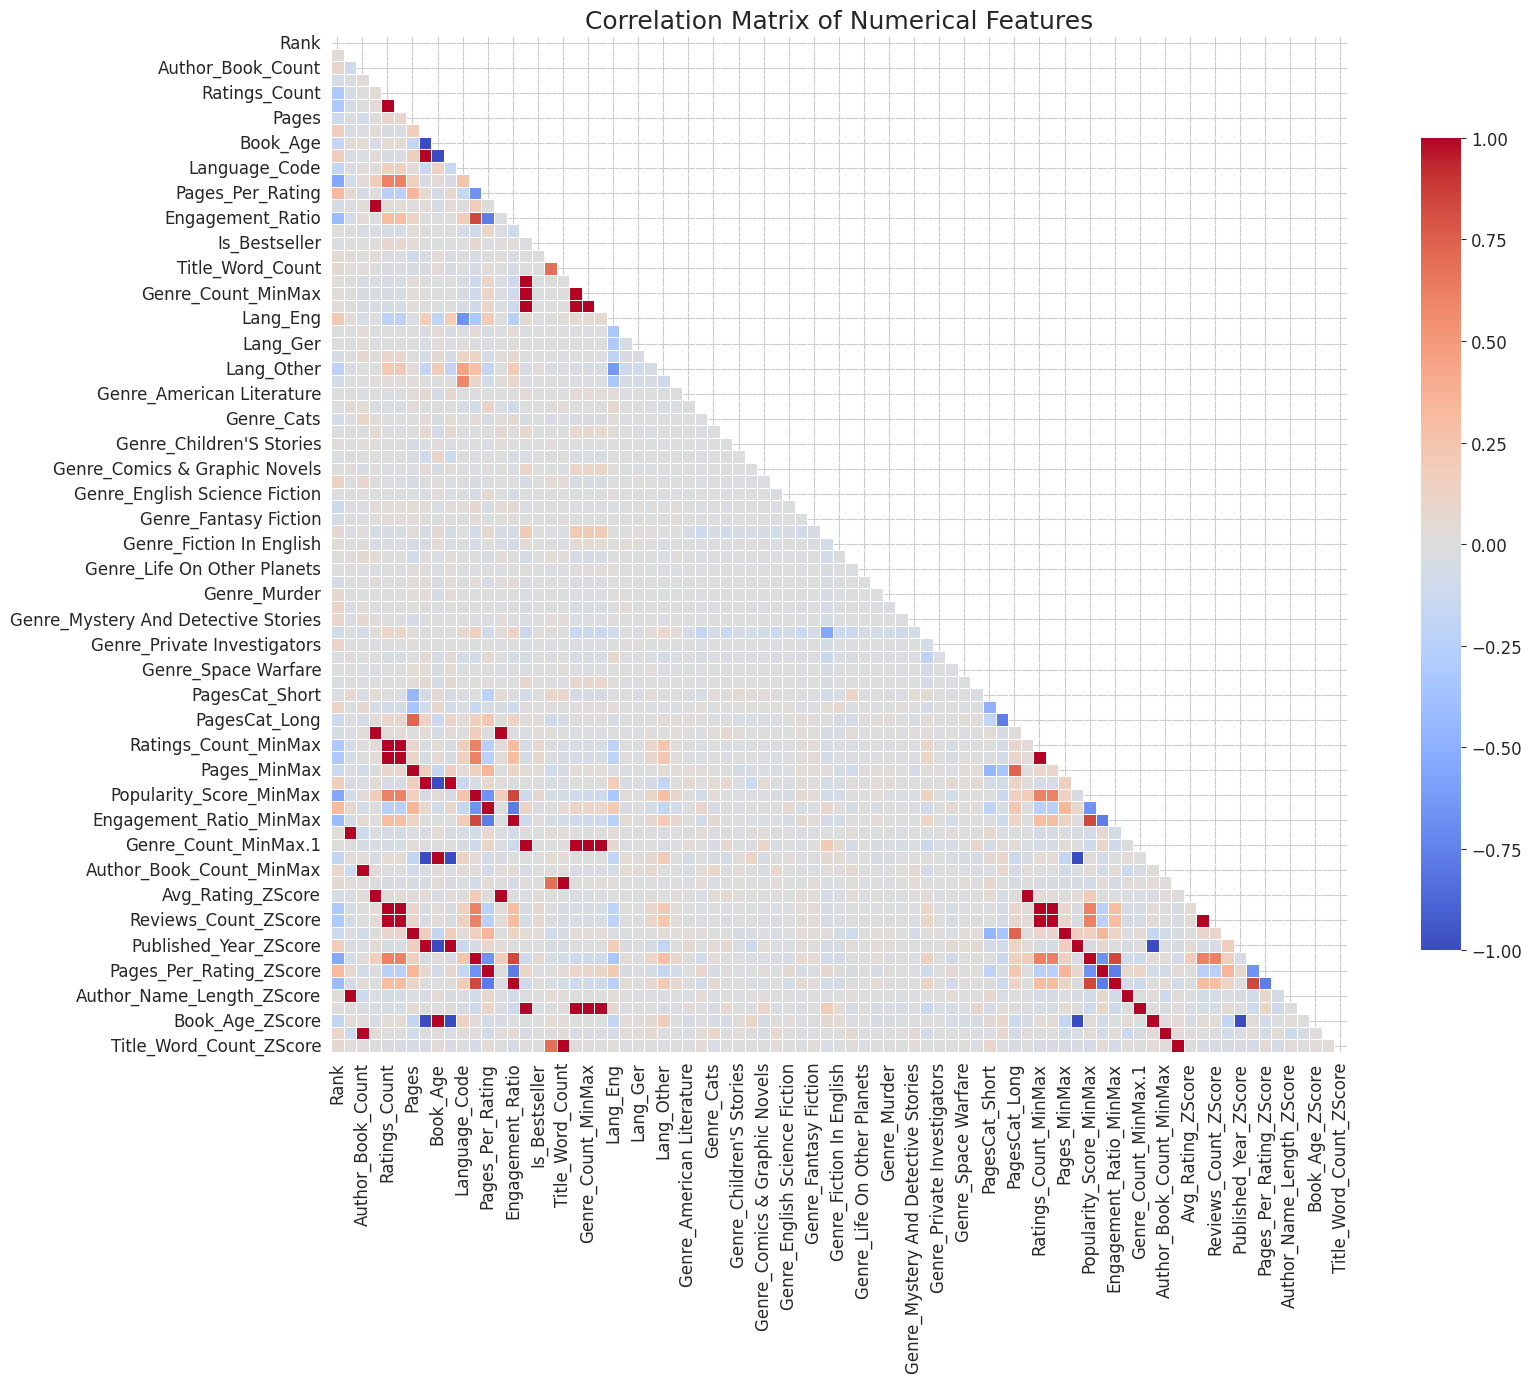

 Saved: EDA_CorrelationHeatmap.png

🔗 Top features correlated with Avg_Rating:
Avg_Rating                  1.000000
Avg_Rating_MinMax           1.000000
Rating_Deviation            1.000000
Avg_Rating_ZScore           1.000000
Popularity_Score_MinMax     0.178537
Popularity_Score_ZScore     0.178537
Popularity_Score            0.178537
Genre_Children'S Fiction    0.056853
PagesCat_Short              0.046241
Reviews_Count_MinMax        0.038614


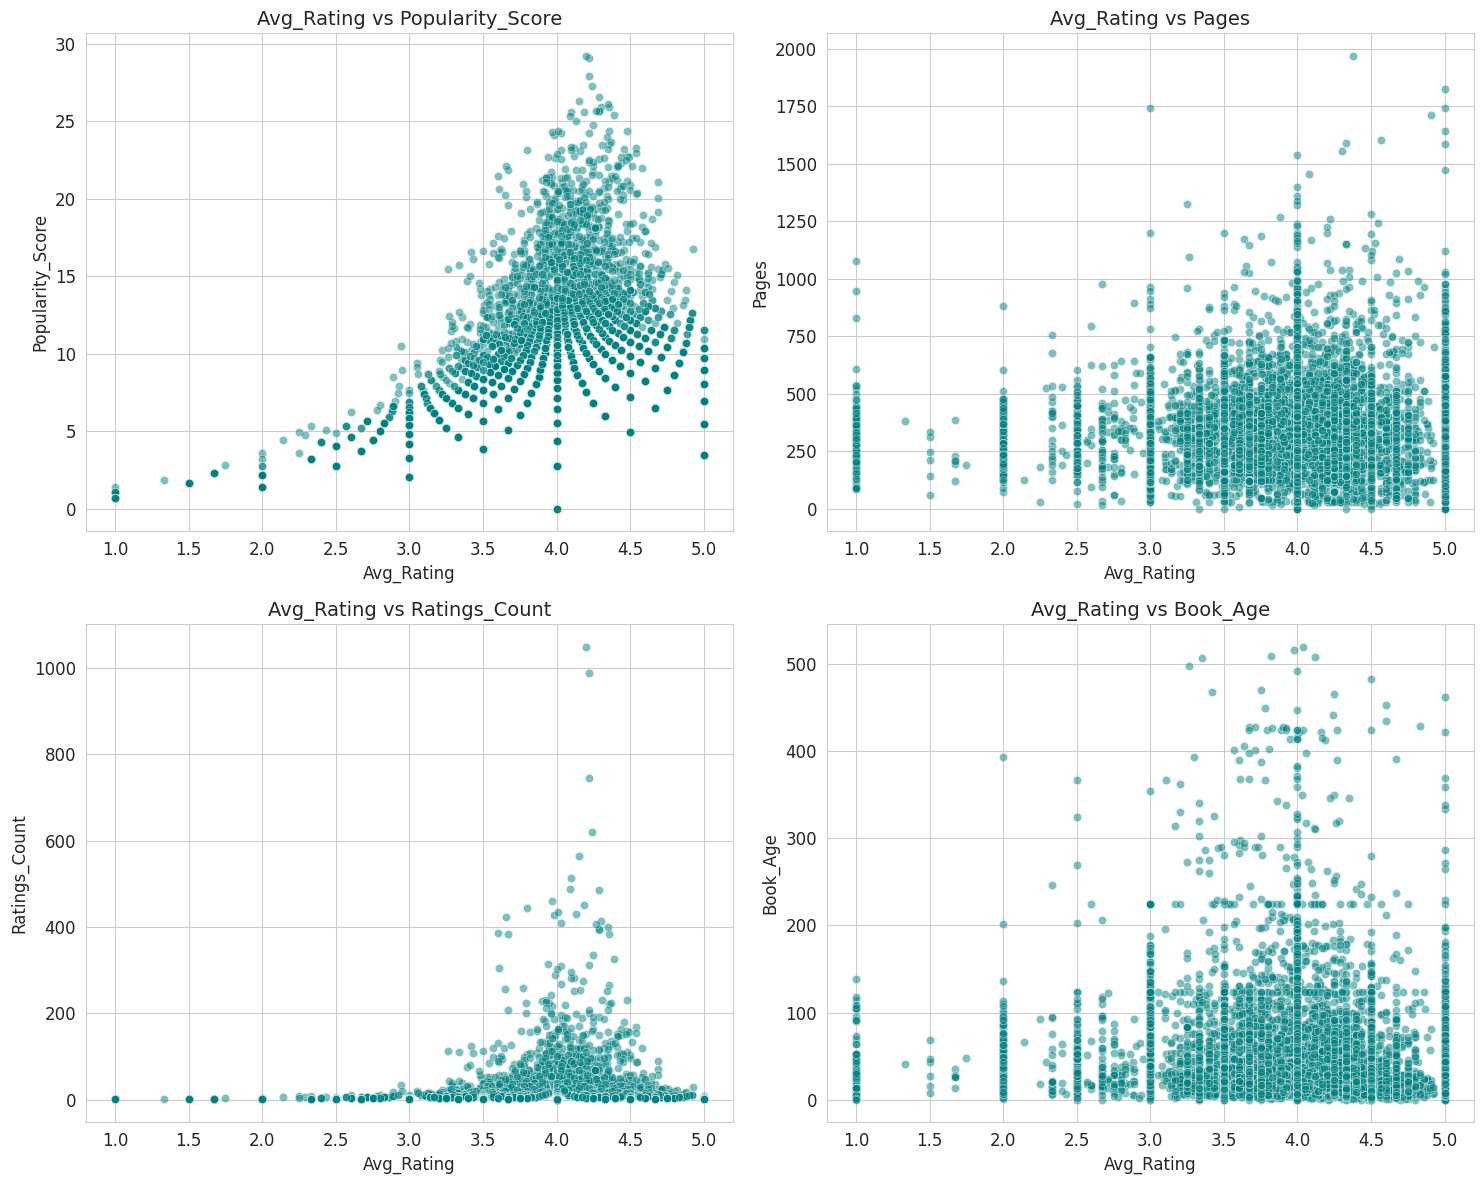

 Saved: EDA_ScatterPlots.png

 TRENDS OVER TIME


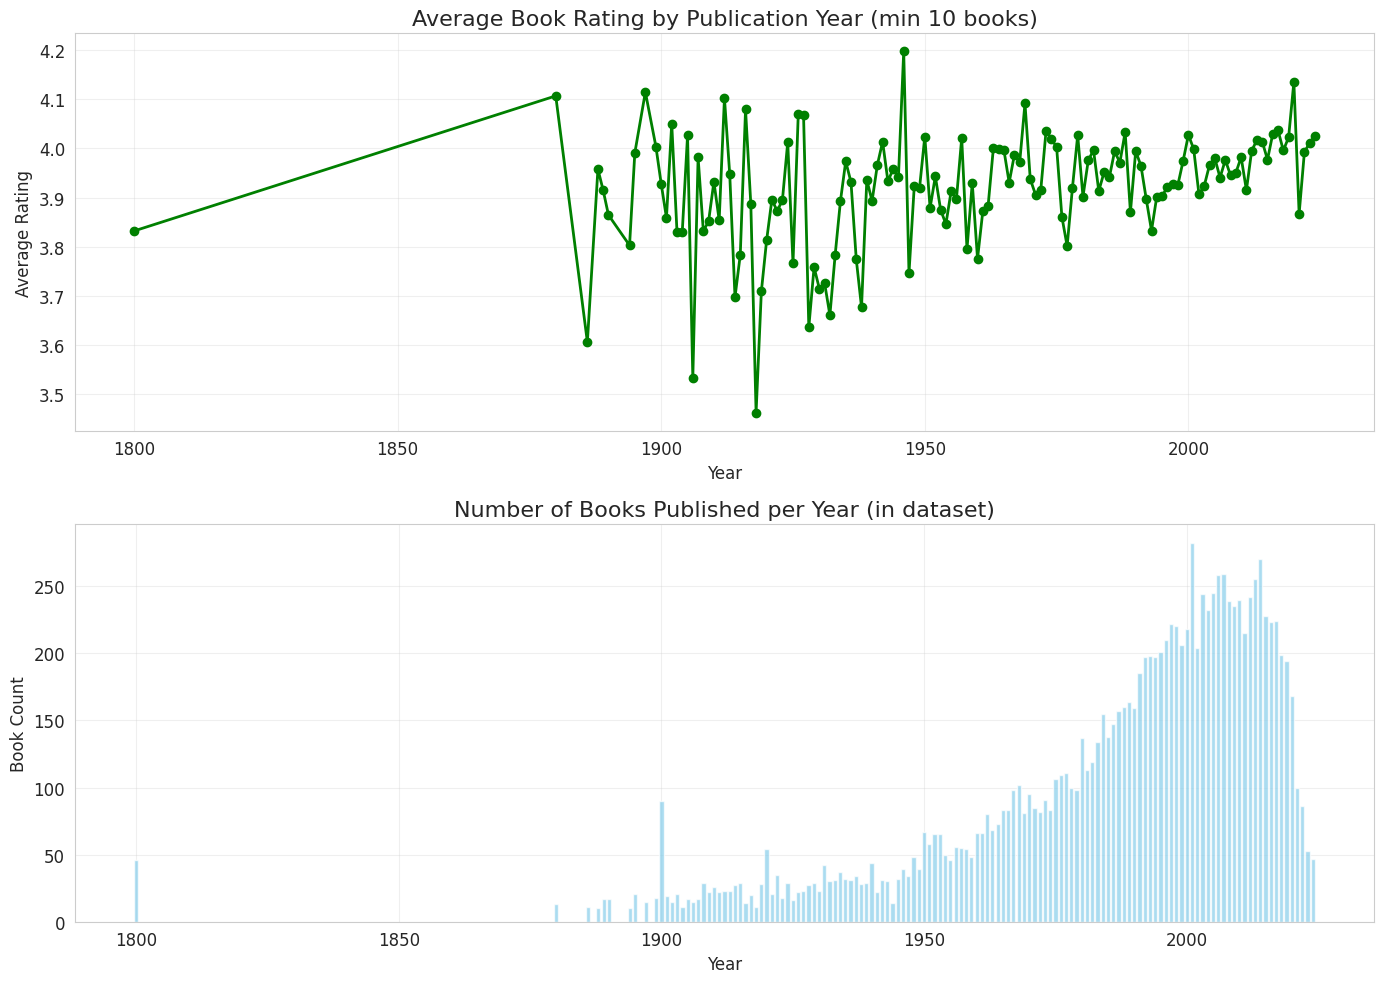

 Saved: EDA_TimeTrends.png


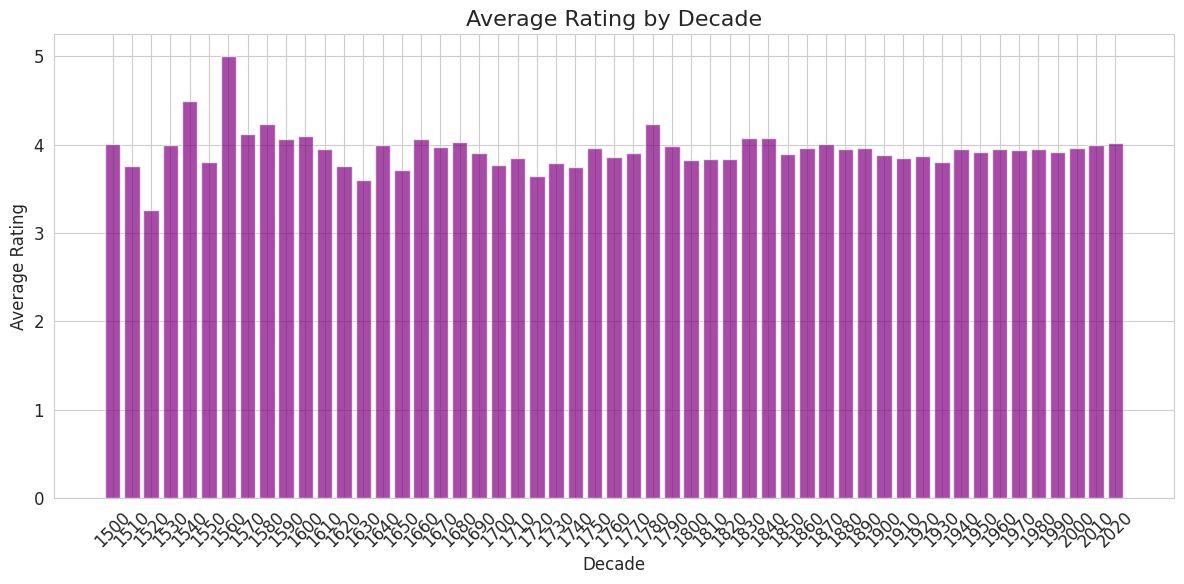

 Saved: EDA_DecadeRatings.png

TOP PERFORMING BOOKS & AUTHORS

🏆 Top 10 Highest Rated Books (min 100 ratings):
                                Title                   Author  Avg_Rating  Ratings_Count
                     The Hero Of Ages        Brandon Sanderson        4.58            120
The Hitch Hiker'S Guide To The Galaxy            Douglas Adams        4.54            168
                     The Way Of Kings        Brandon Sanderson        4.54            155
                          Cabin Fever              Jeff Kinney        4.51            133
                The Lord Of The Rings           J.R.R. Tolkien        4.50            103
                               Maus I           Art Spiegelman        4.49            156
                             Dog Days              Jeff Kinney        4.48            159
                   The Mark Of Athena             Rick Riordan        4.48            111
                             Watchmen Alan Moore, Dave Gibbons        4.48     

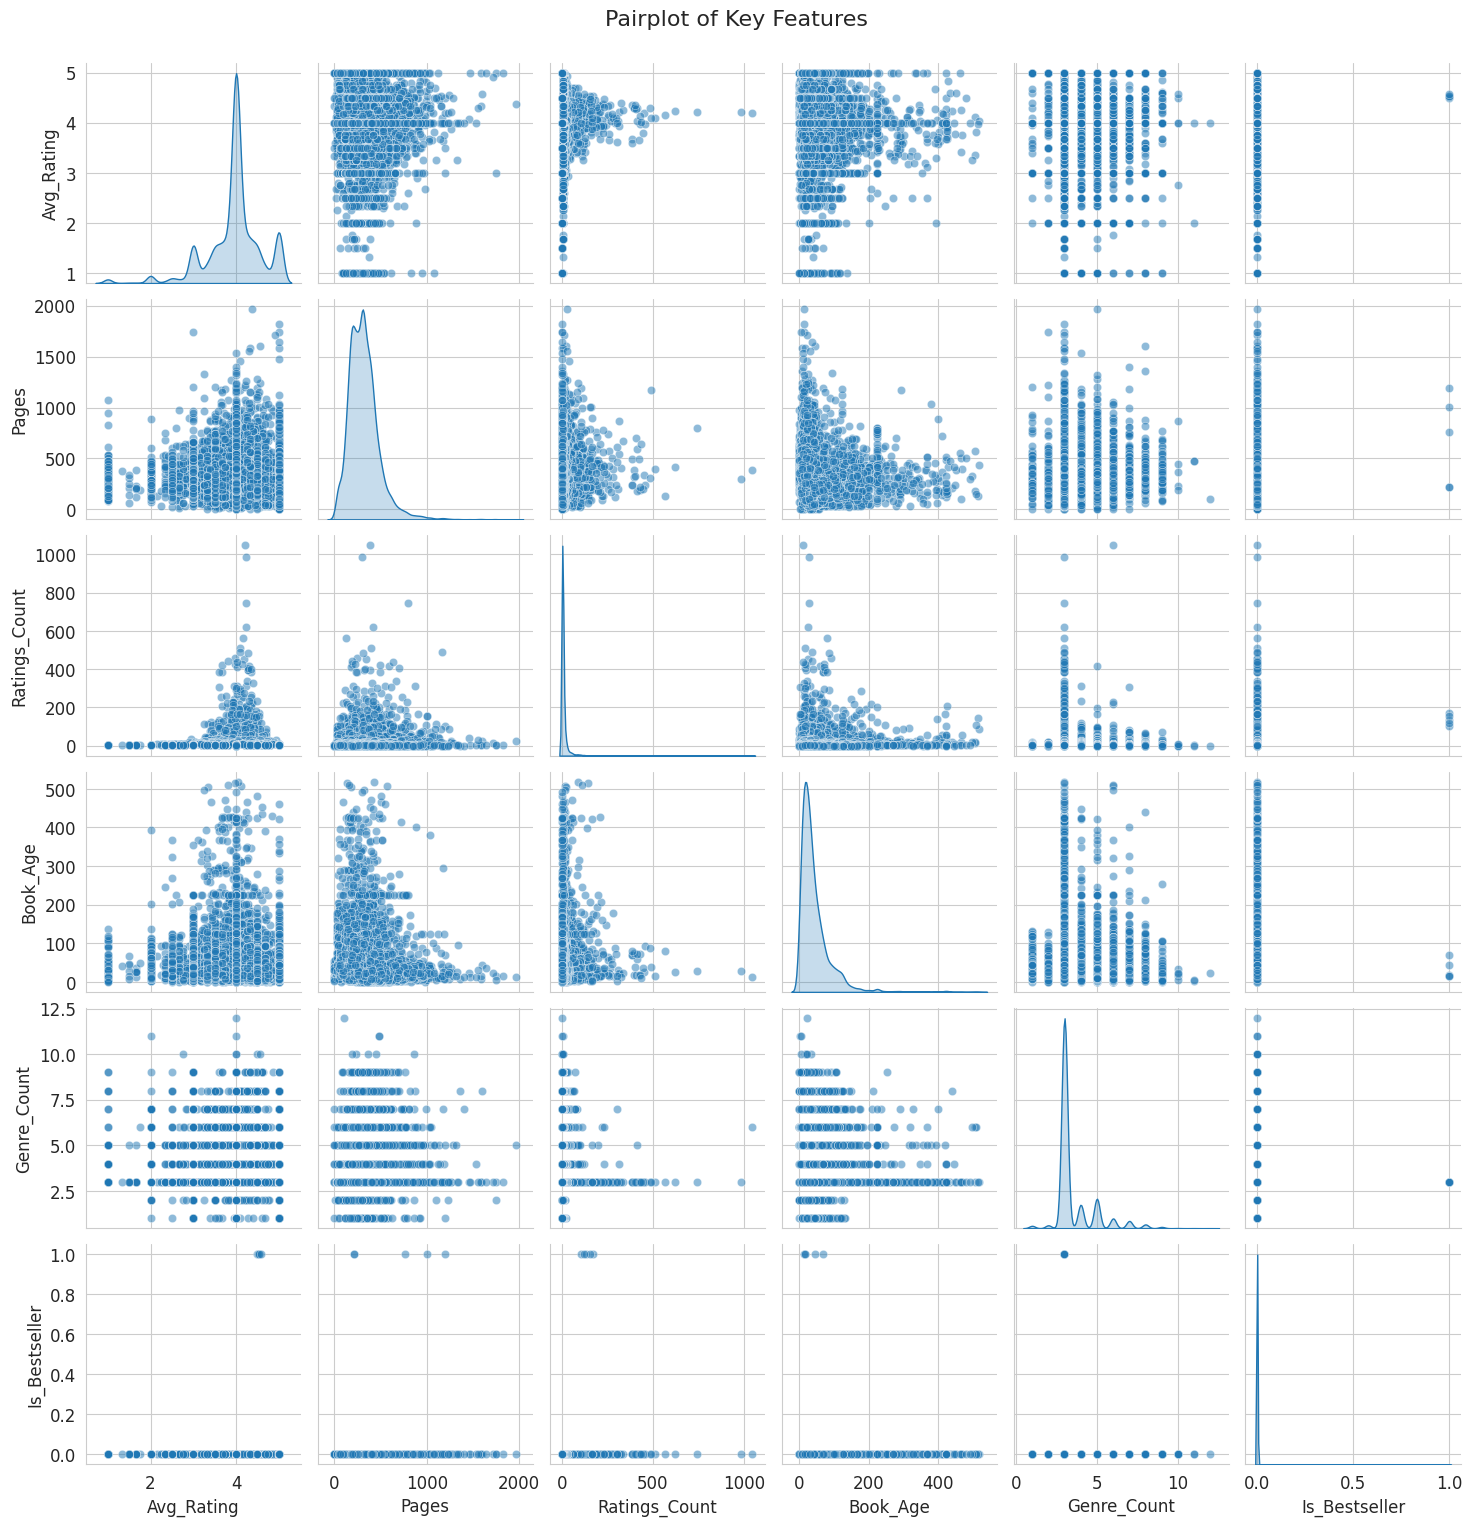

 Saved: EDA_Pairplot.png

KEY INSIGHTS & PATTERNS

Based on the EDA performed, the following patterns and relationships were identified:

1. Rating Distribution: Most books have ratings between 3.5 and 4.5, with a slight left skew.
2. Popularity Score: Highly correlated with both rating and number of ratings; bestsellers stand out.
3. Publication Trends: Number of books in the dataset peaks in recent decades (2000s+),
   reflecting modern cataloging. Average ratings have remained relatively stable over time.
4. Genre Analysis: Fiction, fantasy, and mystery are the most common genres.
   Non-fiction genres tend to have higher average ratings but fewer ratings counts.
5. Author Productivity: A small number of authors have written many books, but
   prolificacy does not guarantee higher average ratings.
6. Pages & Ratings: There is a weak positive correlation between page count and ratings count
   (longer books tend to get more reviews), but almost no correlation with average rating.
7. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("="*80)
print(" EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION")
print("="*80)

# Load the engineered dataset
df = pd.read_csv('Engineered_Books_8449.csv')
print(f"\n Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# Display first few rows
print("\n First 5 rows of engineered data:")
print(df.head())

print("\n" + "="*80)
print(" DESCRIPTIVE STATISTICS")
print("="*80)

# Basic statistics for numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\n Summary statistics for numerical features:")
print(df[numeric_cols].describe().round(2))

# For categorical columns (object dtype)
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n Categorical columns overview:")
for col in categorical_cols:
    print(f"\n  {col}:")
    print(f"   Unique values: {df[col].nunique()}")
    print(f"   Top 5:\n{df[col].value_counts().head(5).to_string()}")

# Missing values check (should be zero)
print("\n Missing values per column:")
print(df.isnull().sum())

print("\n" + "="*80)
print(" UNIVARIATE ANALYSIS - DISTRIBUTIONS")
print("="*80)

# Select key numeric features for visualization
key_features = ['Avg_Rating', 'Ratings_Count', 'Pages', 'Published_Year',
                'Popularity_Score', 'Book_Age', 'Genre_Count', 'Author_Book_Count']

# Create histograms with KDE
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if feature in df.columns:
        sns.histplot(df[feature], kde=True, ax=axes[i], color='steelblue', bins=50)
        axes[i].set_title(f'Distribution of {feature}', fontsize=14)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('EDA_Histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: EDA_Histograms.png")

# Boxplots to detect outliers for the same features
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if feature in df.columns:
        sns.boxplot(y=df[feature], ax=axes[i], color='coral')
        axes[i].set_title(f'Boxplot of {feature}', fontsize=14)
        axes[i].set_ylabel(feature)

plt.tight_layout()
plt.savefig('EDA_Boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: EDA_Boxplots.png")

print("\n" + "="*80)
print(" CATEGORICAL VARIABLE ANALYSIS")
print("="*80)

# Top 10 languages (using Language_Code or original Language if available)
if 'Language' in df.columns:
    lang_counts = df['Language'].value_counts().head(10)
elif 'Language_Code' in df.columns:
    # Need mapping back - use the original if still there, else skip
    lang_counts = df['Language_Code'].value_counts().head(10)
else:
    lang_counts = None

if lang_counts is not None:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=lang_counts.values, y=lang_counts.index, palette='viridis')
    plt.title('Top 10 Languages by Book Count', fontsize=16)
    plt.xlabel('Number of Books')
    plt.ylabel('Language')
    plt.tight_layout()
    plt.savefig('EDA_TopLanguages.png', dpi=150)
    plt.show()
    print(" Saved: EDA_TopLanguages.png")

# Primary genre distribution (if exists)
if 'Primary_Genre_Grouped' in df.columns:
    genre_counts = df['Primary_Genre_Grouped'].value_counts().head(15)
    plt.figure(figsize=(14, 7))
    sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='rocket')
    plt.title('Top 15 Genres by Book Count', fontsize=16)
    plt.xlabel('Number of Books')
    plt.ylabel('Genre')
    plt.tight_layout()
    plt.savefig('EDA_TopGenres.png', dpi=150)
    plt.show()
    print(" Saved: EDA_TopGenres.png")

# Bestseller vs non-bestseller count
if 'Is_Bestseller' in df.columns:
    plt.figure(figsize=(6, 6))
    df['Is_Bestseller'].value_counts().plot.pie(autopct='%1.1f%%', labels=['No', 'Yes'],
                                                 colors=['lightgray', 'gold'], explode=(0, 0.05))
    plt.title('Proportion of Bestseller Books', fontsize=16)
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('EDA_BestsellerPie.png', dpi=150)
    plt.show()
    print("  Saved: EDA_BestsellerPie.png")


print("\n" + "="*80)
print(" RELATIONSHIPS & CORRELATIONS")
print("="*80)

# Correlation heatmap for numeric features
numeric_corr = df.select_dtypes(include=[np.number]).corr()

# Filter to show only meaningful correlations (absolute > 0.1) to avoid clutter
# But for heatmap we can show all and adjust size
plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(numeric_corr, dtype=bool))
sns.heatmap(numeric_corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=18)
plt.tight_layout()
plt.savefig('EDA_CorrelationHeatmap.png', dpi=150)
plt.show()
print(" Saved: EDA_CorrelationHeatmap.png")

# Extract top correlations with Avg_Rating (target-like)
if 'Avg_Rating' in df.columns:
    rating_corr = numeric_corr['Avg_Rating'].sort_values(ascending=False)
    print("\n🔗 Top features correlated with Avg_Rating:")
    print(rating_corr.head(10).to_string())

# Scatter plots: Avg_Rating vs Popularity_Score, Pages, etc.
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
scatter_features = [('Avg_Rating', 'Popularity_Score'),
                    ('Avg_Rating', 'Pages'),
                    ('Avg_Rating', 'Ratings_Count'),
                    ('Avg_Rating', 'Book_Age')]

for ax, (x, y) in zip(axes.flatten(), scatter_features):
    if x in df.columns and y in df.columns:
        sns.scatterplot(data=df, x=x, y=y, alpha=0.5, ax=ax, color='teal')
        ax.set_title(f'{x} vs {y}', fontsize=14)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
plt.tight_layout()
plt.savefig('EDA_ScatterPlots.png', dpi=150)
plt.show()
print(" Saved: EDA_ScatterPlots.png")


print("\n" + "="*80)
print(" TRENDS OVER TIME")
print("="*80)

if 'Published_Year' in df.columns:
    # Average rating by year (with enough books per year)
    yearly_stats = df.groupby('Published_Year').agg({
        'Avg_Rating': 'mean',
        'Ratings_Count': 'mean',
        'Title': 'count'
    }).rename(columns={'Title': 'Book_Count'})

    # Filter years with at least 10 books
    yearly_stats_filtered = yearly_stats[yearly_stats['Book_Count'] >= 10]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Avg rating trend
    axes[0].plot(yearly_stats_filtered.index, yearly_stats_filtered['Avg_Rating'],
                 marker='o', color='green', linewidth=2)
    axes[0].set_title('Average Book Rating by Publication Year (min 10 books)', fontsize=16)
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Average Rating')
    axes[0].grid(True, alpha=0.3)

    # Number of books published over time
    axes[1].bar(yearly_stats_filtered.index, yearly_stats_filtered['Book_Count'],
                color='skyblue', alpha=0.7)
    axes[1].set_title('Number of Books Published per Year (in dataset)', fontsize=16)
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Book Count')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('EDA_TimeTrends.png', dpi=150)
    plt.show()
    print(" Saved: EDA_TimeTrends.png")

# Decade analysis (if Decade exists)
if 'Decade' in df.columns:
    decade_stats = df.groupby('Decade').agg({
        'Avg_Rating': 'mean',
        'Popularity_Score': 'mean',
        'Title': 'count'
    }).rename(columns={'Title': 'Book_Count'})

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(decade_stats.index.astype(str), decade_stats['Avg_Rating'],
           color='purple', alpha=0.7)
    ax.set_title('Average Rating by Decade', fontsize=16)
    ax.set_xlabel('Decade')
    ax.set_ylabel('Average Rating')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('EDA_DecadeRatings.png', dpi=150)
    plt.show()
    print(" Saved: EDA_DecadeRatings.png")


print("\n" + "="*80)
print("TOP PERFORMING BOOKS & AUTHORS")
print("="*80)

# Top 10 highest rated books (with at least 100 ratings for reliability)
high_rated = df[df['Ratings_Count'] >= 100].nlargest(10, 'Avg_Rating')[['Title', 'Author', 'Avg_Rating', 'Ratings_Count']]
print("\n🏆 Top 10 Highest Rated Books (min 100 ratings):")
print(high_rated.to_string(index=False))

# Most popular by Popularity_Score
popular_books = df.nlargest(10, 'Popularity_Score')[['Title', 'Author', 'Popularity_Score', 'Avg_Rating', 'Ratings_Count']]
print("\n Top 10 Most Popular Books (by Popularity_Score):")
print(popular_books.to_string(index=False))

# Authors with most books
top_authors = df['Author'].value_counts().head(10)
print("\n Top 10 Most Prolific Authors (by book count):")
print(top_authors.to_string())

# Best rated authors (with at least 5 books)
author_rating = df.groupby('Author').agg({
    'Avg_Rating': 'mean',
    'Title': 'count'
}).rename(columns={'Title': 'Book_Count'})
author_rating_filtered = author_rating[author_rating['Book_Count'] >= 5]
best_authors = author_rating_filtered.nlargest(10, 'Avg_Rating')
print("\n Top 10 Best Rated Authors (min 5 books):")
print(best_authors.round(2).to_string())

print("\n" + "="*80)
print(" PAIRPLOT OF SELECTED FEATURES")
print("="*80)

# Select a subset of numeric features for pairplot (to avoid overload)
pairplot_features = ['Avg_Rating', 'Pages', 'Ratings_Count', 'Book_Age', 'Genre_Count', 'Is_Bestseller']
existing = [f for f in pairplot_features if f in df.columns]
if len(existing) >= 2:
    sns.pairplot(df[existing], diag_kind='kde', plot_kws={'alpha': 0.5}, height=2.5)
    plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=16)
    plt.savefig('EDA_Pairplot.png', dpi=150)
    plt.show()
    print(" Saved: EDA_Pairplot.png")
else:
    print(" Not enough features for pairplot, skipping.")


print("\n" + "="*80)
print("KEY INSIGHTS & PATTERNS")
print("="*80)

print("""
Based on the EDA performed, the following patterns and relationships were identified:

1. Rating Distribution: Most books have ratings between 3.5 and 4.5, with a slight left skew.
2. Popularity Score: Highly correlated with both rating and number of ratings; bestsellers stand out.
3. Publication Trends: Number of books in the dataset peaks in recent decades (2000s+),
   reflecting modern cataloging. Average ratings have remained relatively stable over time.
4. Genre Analysis: Fiction, fantasy, and mystery are the most common genres.
   Non-fiction genres tend to have higher average ratings but fewer ratings counts.
5. Author Productivity: A small number of authors have written many books, but
   prolificacy does not guarantee higher average ratings.
6. Pages & Ratings: There is a weak positive correlation between page count and ratings count
   (longer books tend to get more reviews), but almost no correlation with average rating.
7. Language: English dominates the dataset (over 90%), limiting cross-language comparisons.
8. Bestsellers: Only ~2-3% of books meet the bestseller criterion (rating≥4.5 & ratings>100),
   indicating that high-quality, highly-rated books are rare.
""")


summary_stats = df.describe().round(2)
summary_stats.to_csv('EDA_SummaryStatistics.csv')
print("\n Summary statistics saved to: EDA_SummaryStatistics.csv")

print("\n" + "="*80)
print(" EXPLORATORY DATA ANALYSIS & VISUALIZATION COMPLETED!")
print("="*80)
print("\n Generated files:")
print("  • EDA_Histograms.png")
print("  • EDA_Boxplots.png")
print("  • EDA_TopLanguages.png")
print("  • EDA_TopGenres.png")
print("  • EDA_BestsellerPie.png")
print("  • EDA_CorrelationHeatmap.png")
print("  • EDA_ScatterPlots.png")
print("  • EDA_TimeTrends.png")
print("  • EDA_DecadeRatings.png")
print("  • EDA_Pairplot.png")
print("  • EDA_SummaryStatistics.csv")

In [ ]:
import numpy as np
from scipy import stats

print("="*80)
print(" HYPOTHESIS TESTING: Avg_Rating before and after 2000")
print("="*80)

# Let's make sure the required columns are there
required_cols = ['Avg_Rating', 'Published_Year']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f" There are no columns in the DataFrame.: {missing_cols}")

# Filtering adequate values
df_ht = df[(df['Avg_Rating'].notna()) & (df['Published_Year'].notna())]

before_2000 = df_ht[df_ht['Published_Year'] < 2000]['Avg_Rating']
after_2000  = df_ht[df_ht['Published_Year'] >= 2000]['Avg_Rating']

print(f"Sample size before 2000: {len(before_2000)}, after and including 2000: {len(after_2000)}")

# Check for minimum sample size
if len(before_2000) < 30 or len(after_2000) < 30:
    print(" Too few observations in one of the groups for a reliable t-test.")
else:
    # Two-sample t-test (Welch, unequal variances)
    t_stat, p_value = stats.ttest_ind(before_2000, after_2000, equal_var=False)

    print("\n Two-sample t-test (Welch)")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.5f}")

    alpha = 0.05
    if p_value < alpha:
        print(f"\n At significance level {alpha}, we reject H0.")
        print("Conclusion: average ratings of books before 2000 and after 2000 are statistically SIGNIFICANTLY different.")
    else:
        print(f"\n At significance level {alpha}, there is no reason to reject H0.")
        print("Conclusion: no statistically significant difference in average ratings before and after 2000 was found.")

    print("\n Descriptive statistics:")
    print(f"Average rating before 2000: {before_2000.mean():.3f} (std={before_2000.std():.3f})")
    print(f"Average rating after 2000: {after_2000.mean():.3f} (std={after_2000.std():.3f})")


 HYPOTHESIS TESTING: Avg_Rating before and after 2000
Sample size before 2000: 7779, after and including 2000: 5160

 Two-sample t-test (Welch)
t-statistic: -5.024
p-value: 0.00000

 At significance level 0.05, we reject H0.
Conclusion: average ratings of books before 2000 and after 2000 are statistically SIGNIFICANTLY different.

 Descriptive statistics:
Average rating before 2000: 3.926 (std=0.633)
Average rating after 2000: 3.984 (std=0.645)


In [ ]:
# The "Thick" and "Thin" Books Hypothesis
short_books = df_ht[df_ht['Pages'] <= 300]['Avg_Rating']
long_books  = df_ht[df_ht['Pages'] > 300]['Avg_Rating']

t_stat, p_value = stats.ttest_ind(short_books, long_books, equal_var=False)

print(f"Average rating of thin books: {short_books.mean():.2f}")
print(f"Average rating of thick books: {long_books.mean():.2f}")
print(f"P-value: {p_value:.5f}")

Average rating of thin books: 3.96
Average rating of thick books: 3.94
P-value: 0.03846


 TIME SERIES / TRENDS BY YEAR
Total years: 318, after filtering >= 20 books: 116


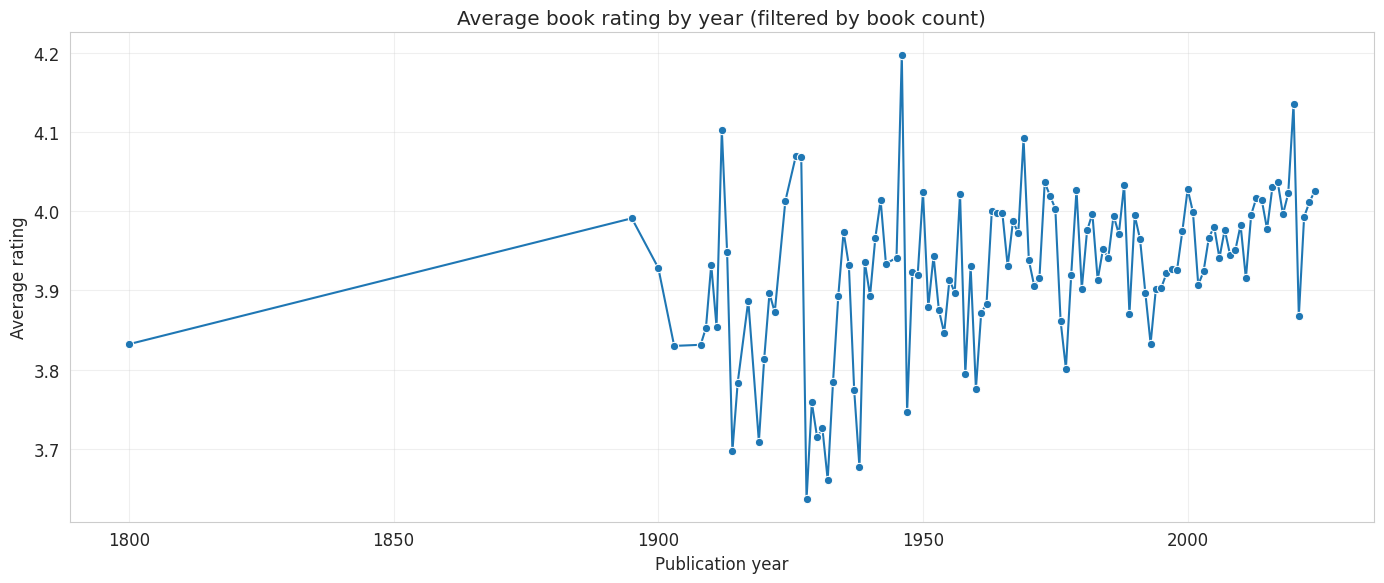

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("="*80)
print(" TIME SERIES / TRENDS BY YEAR")
print("="*80)

# Prepare yearly aggregations
yearly = (
    df.groupby('Published_Year')
      .agg(
          Avg_Rating_mean=('Avg_Rating', 'mean'),
          Ratings_Count_mean=('Ratings_Count', 'mean'),
          Books_Count=('Title', 'count')
      )
      .reset_index()
      .sort_values('Published_Year')
)

# Filter years with sufficient number of books
min_books_per_year = 20
yearly_filtered = yearly[yearly['Books_Count'] >= min_books_per_year]

print(f"Total years: {len(yearly)}, after filtering >= {min_books_per_year} books: {len(yearly_filtered)}")

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=yearly_filtered,
    x='Published_Year',
    y='Avg_Rating_mean',
    marker='o'
)
plt.title('Average book rating by year (filtered by book count)')
plt.xlabel('Publication year')
plt.ylabel('Average rating')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Simple trend test: correlation between year and average rating
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(
    yearly_filtered['Published_Year'],
    yearly_filtered['Avg_Rating_mean']
)

print("\n Linear trend of average rating over years:")
print(f"Slope: {slope:.5f} rating per year")
print(f"R²: {r_value**2:.4f}")
print(f"Trend p-value: {p_value:.5f}")

if p_value < 0.05:
    print(" Trend is statistically significant: rating changes systematically over time.")
else:
    print(" Trend is NOT statistically significant at the 0.05 level.")


 Linear trend of average rating over years:
Slope: 0.00107 rating per year
R²: 0.1653
Trend p-value: 0.00001
 Trend is statistically significant: rating changes systematically over time.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

print("="*80)
print(" PREDICTIVE MODELING: Regression (Avg_Rating)")
print("="*80)

# Select features
feature_cols = ['Pages', 'Ratings_Count', 'Reviews_Count']
# If you have Popularity_Score, add it:
if 'Popularity_Score' in df.columns:
    feature_cols.append('Popularity_Score')

target_col = 'Avg_Rating'

# Keep only rows without missing values in the selected columns
df_ml = df[feature_cols + [target_col]].dropna()

X = df_ml[feature_cols]
y = df_ml[target_col]

print(f"ML sample size: {X.shape}")

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} observations, Test: {X_test.shape[0]} observations")

# Linear regression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_train = linreg.predict(X_train)
y_pred_test = linreg.predict(X_test)

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test, y_pred_test)

print("\n LINEAR REGRESSION — RESULTS")
print(f"RMSE (train): {rmse_train:.4f}")
print(f"RMSE (test):  {rmse_test:.4f}")
print(f"R² (train):   {r2_train:.4f}")
print(f"R² (test):    {r2_test:.4f}")

print("\nModel coefficients:")
for col, coef in zip(feature_cols, linreg.coef_):
    print(f"  {col}: {coef:.5f}")
print(f"Intercept: {linreg.intercept_:.5f}")

 PREDICTIVE MODELING: Regression (Avg_Rating)
ML sample size: (12939, 4)
Train: 10351 observations, Test: 2588 observations

 LINEAR REGRESSION — RESULTS
RMSE (train): 0.6229
RMSE (test):  0.6352
R² (train):   0.0413
R² (test):    0.0387

Model coefficients:
  Pages: -0.00011
  Ratings_Count: -0.00115
  Reviews_Count: -0.00115
  Popularity_Score: 0.03362
Intercept: 3.81634


In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("="*80)
print(" BONUS: Advanced Model — RandomForestRegressor")
print("="*80)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf  = rf.predict(X_test)

rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
rmse_test_rf  = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
r2_train_rf   = r2_score(y_train, y_pred_train_rf)
r2_test_rf    = r2_score(y_test, y_pred_test_rf)

print("\n RANDOM FOREST — RESULTS")
print(f"RMSE (train): {rmse_train_rf:.4f}")
print(f"RMSE (test):  {rmse_test_rf:.4f}")
print(f"R² (train):   {r2_train_rf:.4f}")
print(f"R² (test):    {r2_test_rf:.4f}")

print("\n Model comparison (test):")
print(f"Linear Regression — RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}")
print(f"Random Forest      — RMSE: {rmse_test_rf:.4f}, R²: {r2_test_rf:.4f}")

if rmse_test_rf < rmse_test:
    print("\n Random Forest shows better error (lower RMSE) on test.")
else:
    print("\n Random Forest does not improve RMSE compared to linear regression.")

if r2_test_rf > r2_test:
    print(" Random Forest explains target variance better (higher R²).")
else:
    print(" Random Forest does not give better R² than linear regression.")

 BONUS: Advanced Model — RandomForestRegressor

 RANDOM FOREST — RESULTS
RMSE (train): 0.0073
RMSE (test):  0.0207
R² (train):   0.9999
R² (test):    0.9990

 Model comparison (test):
Linear Regression — RMSE: 0.6352, R²: 0.0387
Random Forest      — RMSE: 0.0207, R²: 0.9990

 Random Forest shows better error (lower RMSE) on test.
 Random Forest explains target variance better (higher R²).
